In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

# fielPath = os.path.dirname(os.path.abspath(__file__))   
# dataPath = os.path.join(fielPath, "waveData.csv")
dataPath = "waveData.csv"
# Read the CSV file
waveData = pd.read_csv(dataPath)
time = waveData["Time"].to_numpy()
prob = waveData.iloc[:, 1:].to_numpy()

# Interpolate prob data to 2.0Hz time
time = np.arange(time[0], time[-1], 0.5)
prob_interp = np.zeros((len(time), prob.shape[1]))
for i in range(prob.shape[1]):
    prob_interp[:, i] = np.interp(time, waveData["Time"], prob[:, i])


start_time = pd.Timestamp("2025-01-01")
datetime_index = start_time + pd.to_timedelta(time, unit="s")

prob_interp = prob_interp.astype(np.float32)

# Create a pandas DataFrame
df_interp = pd.DataFrame(prob_interp, index=datetime_index)
df_interp.index.name = "Time"

# Create TimeSeries
ts = TimeSeries.from_dataframe(df_interp)

Train Data, Scale, and Fit

In [2]:
m = 30
n = 10
e = 100
train, val = ts.split_after(0.75)   

scaler = Scaler()

# Scale Data
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
ts_scaled = scaler.transform(ts)

# Fit TCN model
from darts.models import TCNModel

model = TCNModel(input_chunk_length=30,
                 output_chunk_length=10,
                 n_epochs=100,
                 dropout=0.1,
                 kernel_size=5,
                 num_filters=3, 
                 weight_norm=True, 
                 save_checkpoints=True, 
                 random_state=42)

model.fit(series=train_scaled)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 1.2 K  | train
-------------------------------------------------------------
1.2 K     Trainable params
0         Non-trainable params
1.2 K     Total params
0.005     Total estimated model params size (MB)
41        Modules in train mode
0         Modules in eval mode
/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on M

Training: |          | 0/? [00:00<?, ?it/s]

/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:384: `ModelCheckpoint(monitor='val_loss')` could not find the monitored key in the returned metrics: ['train_loss', 'epoch', 'step']. HINT: Did you call `log('val_loss', value)` in the `LightningModule`?
`Trainer.fit` stopped: `max_epochs=100` reached.


TCNModel(output_chunk_shift=0, kernel_size=5, num_filters=3, num_layers=None, dilation_base=2, weight_norm=True, dropout=0.1, input_chunk_length=30, output_chunk_length=10, n_epochs=100, save_checkpoints=True, random_state=42)

In [26]:
backtest = model.historical_forecasts(series=val_scaled,
                                      forecast_horizon=10,
                                      retrain=False,
)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


<Axes: xlabel='time'>

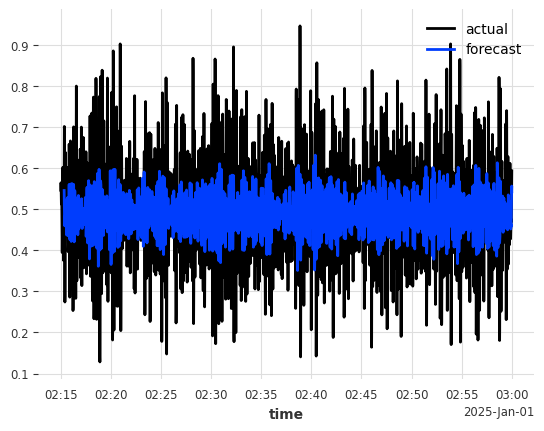

In [27]:
mostDownstream = ts_scaled.components[-1]
val_scaled[mostDownstream].plot(label="actual")
backtest[mostDownstream].plot(label="forecast", lw=2)



**SAVE A MODEL**    


In [24]:
model.save(f"tcn_m_{m}_n{n}_e{e}", "model")

**LOAD A MODEL**

In [25]:
modelName = f"tcn_m_{m}_n{n}_e{e}"
model.load(modelName)

TCNModel(output_chunk_shift=0, kernel_size=5, num_filters=3, num_layers=None, dilation_base=2, weight_norm=True, dropout=0.1, input_chunk_length=30, output_chunk_length=10, n_epochs=100, save_checkpoints=True, random_state=42, pl_trainer_kwargs=None)